In [1]:
%load_ext cuml.accel
%run SSRtransforms_updated.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

2026-03-12 00:21:01.992108: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 00:21:02.036769: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 00:21:02.956078: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 00:21:02.958677: I external/local_xla/xla/tsl/cuda/cudart

In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
synth_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [4]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

## Batch 16

In [11]:
ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

# dataloaders = {x : DataLoader(ds_dict[x], batch_size = 32, num_workers = 5, shuffle = True) for x in ds_dict.keys()}
dataloaders = {
    "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=12, pin_memory = True, persistent_workers=True),
    "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True),
    "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True)
}

In [16]:
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    # Hyperparameters to search
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    eta_min_factor = trial.suggest_float("eta_min_factor", 1e-4, 1e-2, log=True)  # eta_min as fraction of lr

    # Model
    model = models.resnet18(weights="DEFAULT")
    model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = CosineAnnealingLR(optimizer, T_max=150, eta_min=lr * eta_min_factor)

    # Training loop
    num_epochs = 150
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            if phase == "val":
                val_acc = running_corrects / dataset_sizes["val"]
                if val_acc > best_val_acc:
                    best_val_acc = val_acc

        scheduler.step()  # CosineAnnealingLR steps per epoch

        # Pruning — let Optuna kill bad trials early
        trial.report(best_val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_acc


# Run the study
sampler = TPESampler(seed=42)  # reproducible
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner
)

def print_callback(study, trial):
    print(f"Trial {trial.number} finished | Val Acc: {trial.value:.4f} | Params: {trial.params}")
    print(f"Best so far — Trial {study.best_trial.number} | Val Acc: {study.best_value:.4f} | Params: {study.best_params}")
    print("-" * 60)

study.optimize(objective, n_trials=30, callbacks=[print_callback], show_progress_bar=True)

print("Best params:", study.best_params)
print("Best val acc:", study.best_value)

[I 2026-03-11 23:58:36,814] A new study created in memory with name: no-name-ca304efc-ee7a-43d5-84a6-74a8133f8cc7


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-03-12 00:04:14,248] Trial 0 failed with parameters: {'lr': 5.6115164153345e-05, 'weight_decay': 0.006351221010640704, 'optimizer': 'Adam', 'eta_min_factor': 0.0002051338263087451} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/alvinng44/.local/share/mamba/envs/alyssa/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_40407/3843536959.py", line 54, in objective
    running_loss += loss.item() * inputs.size(0)
                    ^^^^^^^^^^^
KeyboardInterrupt
[W 2026-03-12 00:04:14,251] Trial 0 failed with value None.


KeyboardInterrupt: 

In [12]:
train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i in range(10):
    print(f"Training Run {i}")
    # load pre-trained model
    model = models.resnet18(weights = "DEFAULT")

    # Replace final layer for the number of classes
    model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 1e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16_epoch0.pth"))
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16.pth"))

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0
Epoch 0
train Loss: 0.8900550 Acc: 0.6885856
val Loss: 1.7411522 Acc: 0.4280397
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.0519517 Acc: 0.9900744
val Loss: 1.6895418 Acc: 0.4540943
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0329994 Acc: 0.9925558
val Loss: 2.0789912 Acc: 0.3945409
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0171290 Acc: 0.9975186
val Loss: 1.6025481 Acc: 0.5359801
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0131112 Acc: 0.9975186
val Loss: 1.9782464 Acc: 0.4330025
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0196650 Acc: 0.9925558
val Loss: 1.8546483 Acc: 0.4776675
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0224351 Acc: 0.9950372
val Loss: 1.4168201 Acc: 0.6042184
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0294303 Acc: 0.9913151
val Loss: 2.0417098 Acc: 0.4689826
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0284420 Acc: 0.9925558
val Loss: 2.1008015 Acc: 0.4392060
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0445342 Acc: 0.988

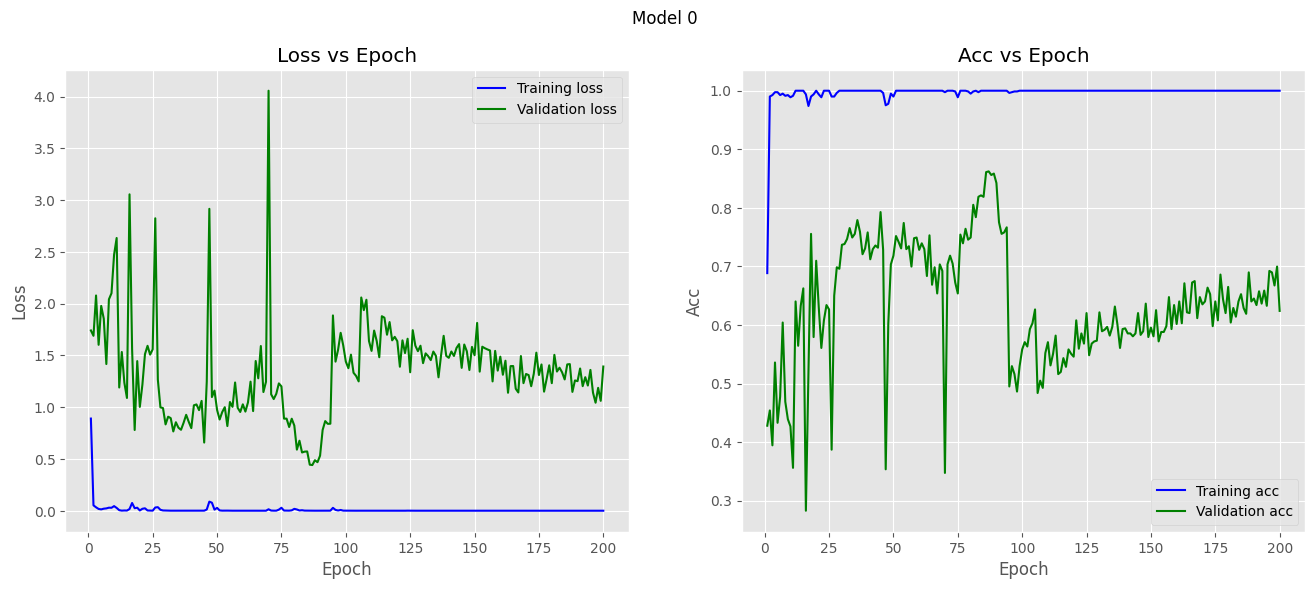

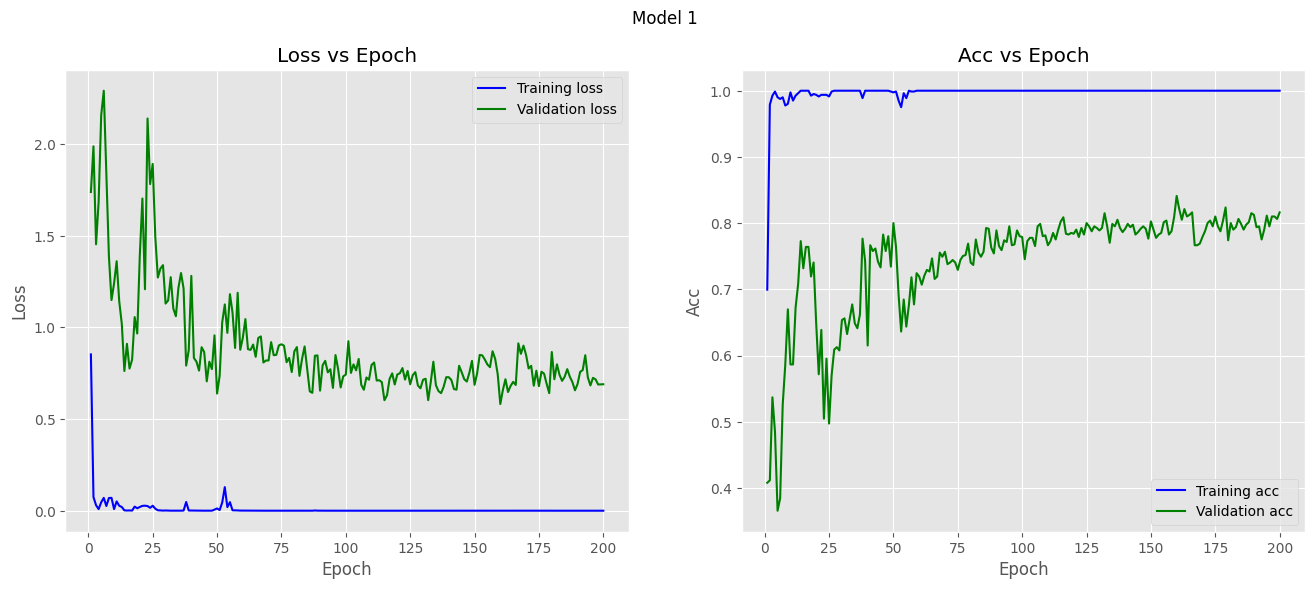

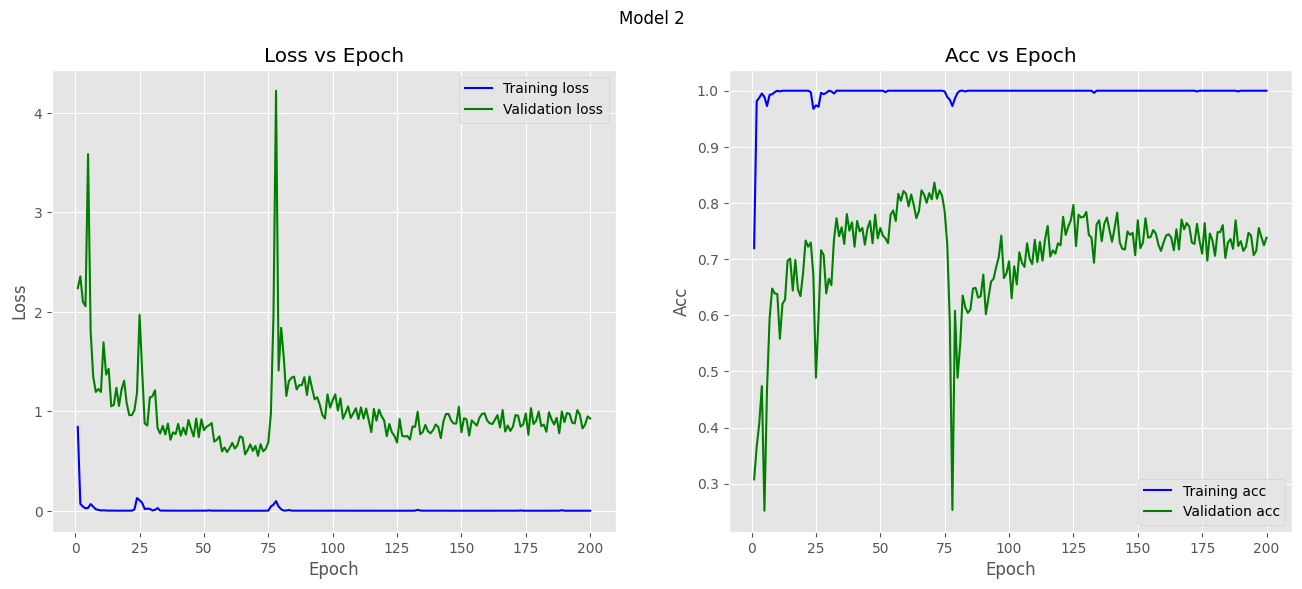

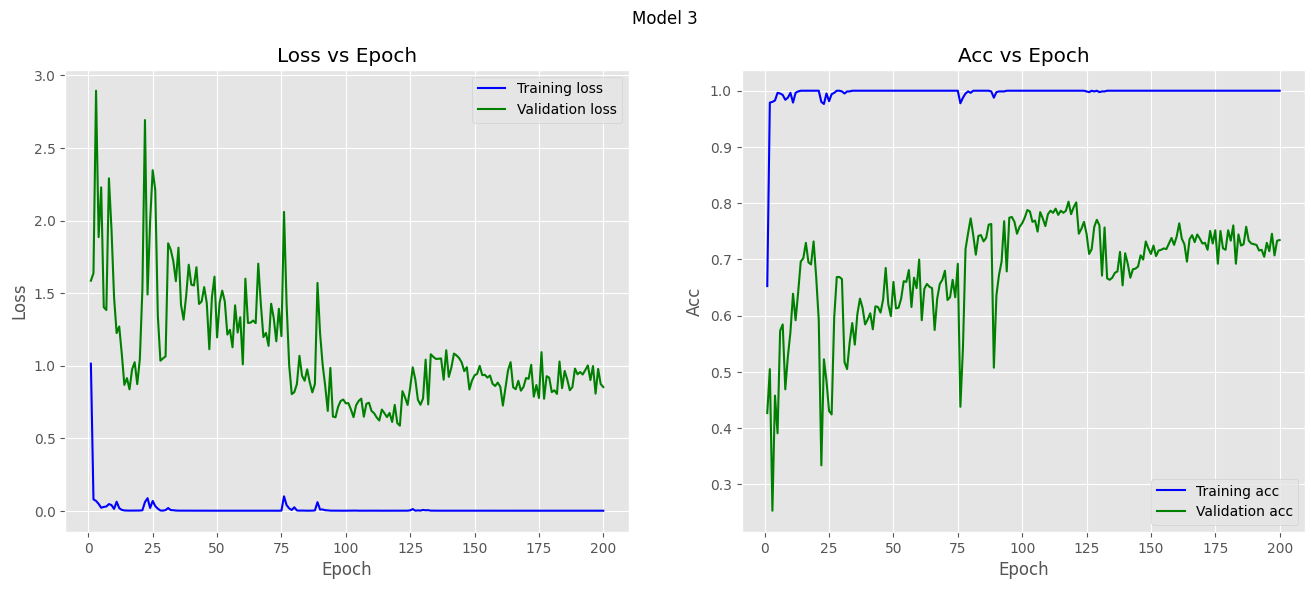

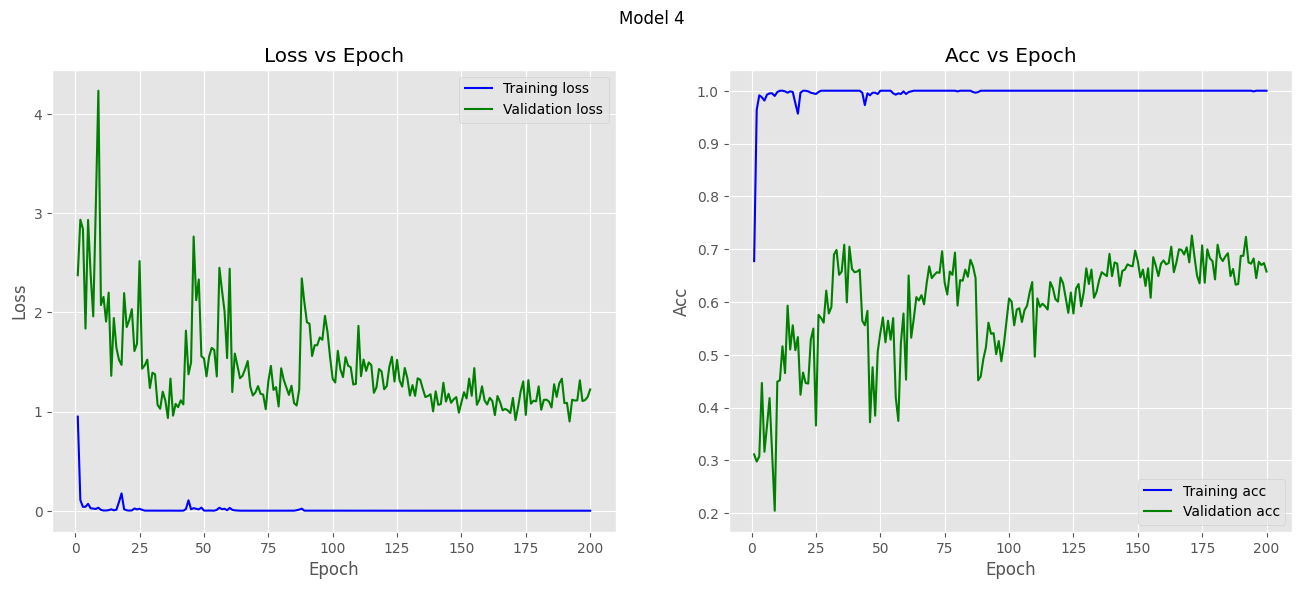

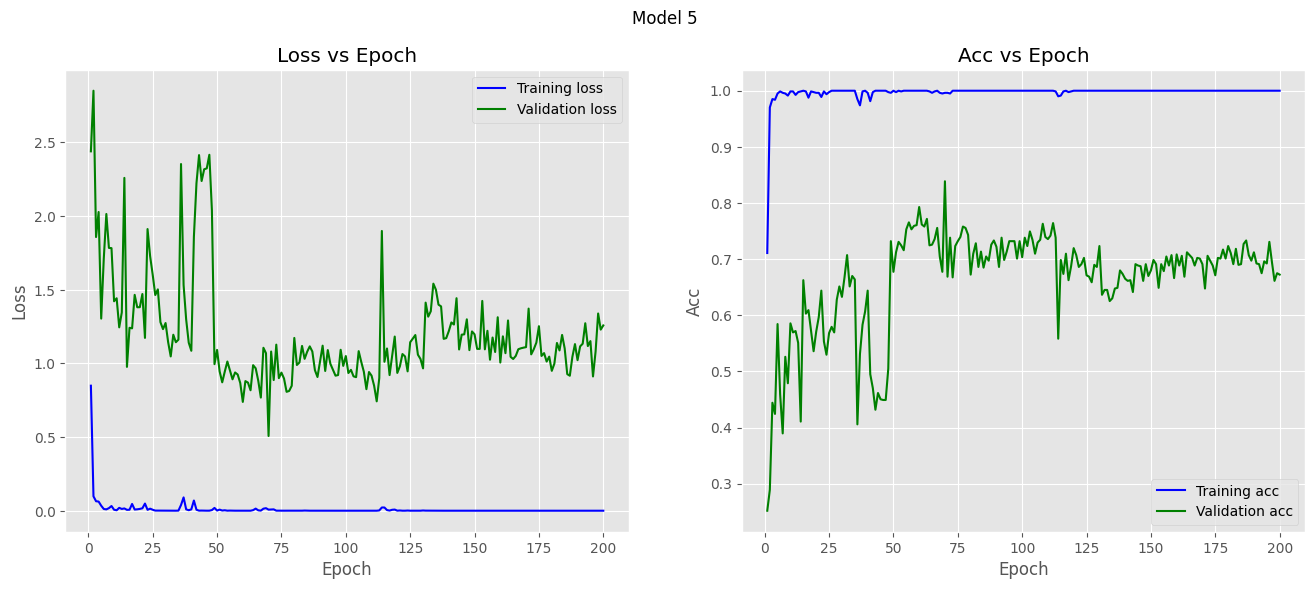

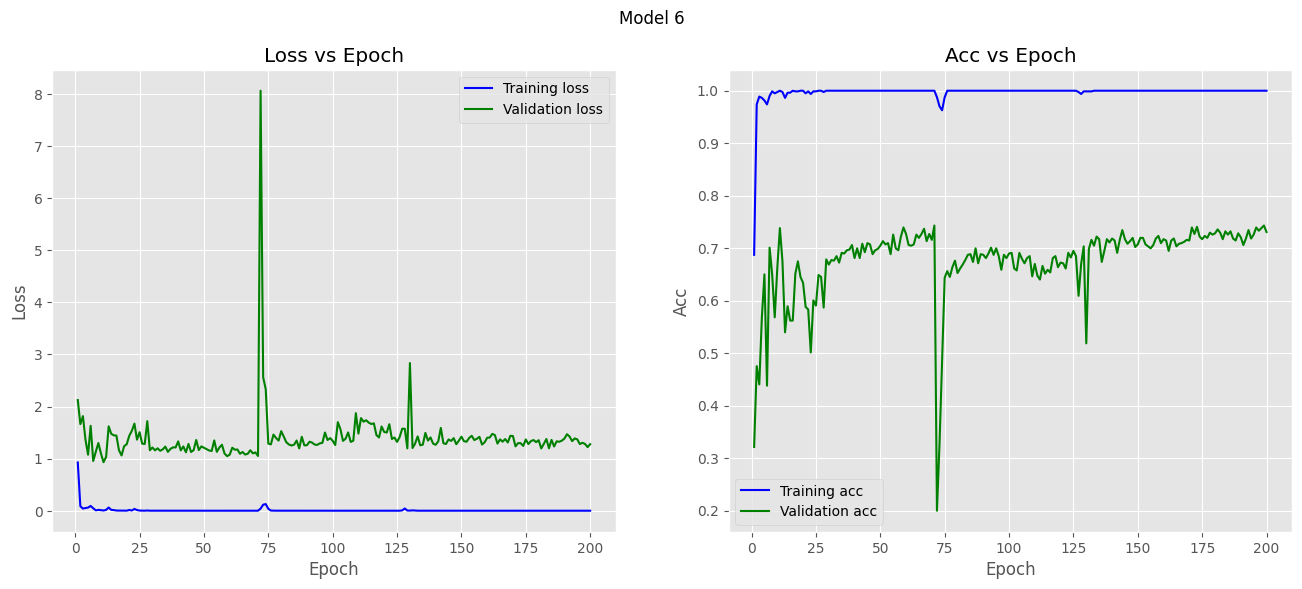

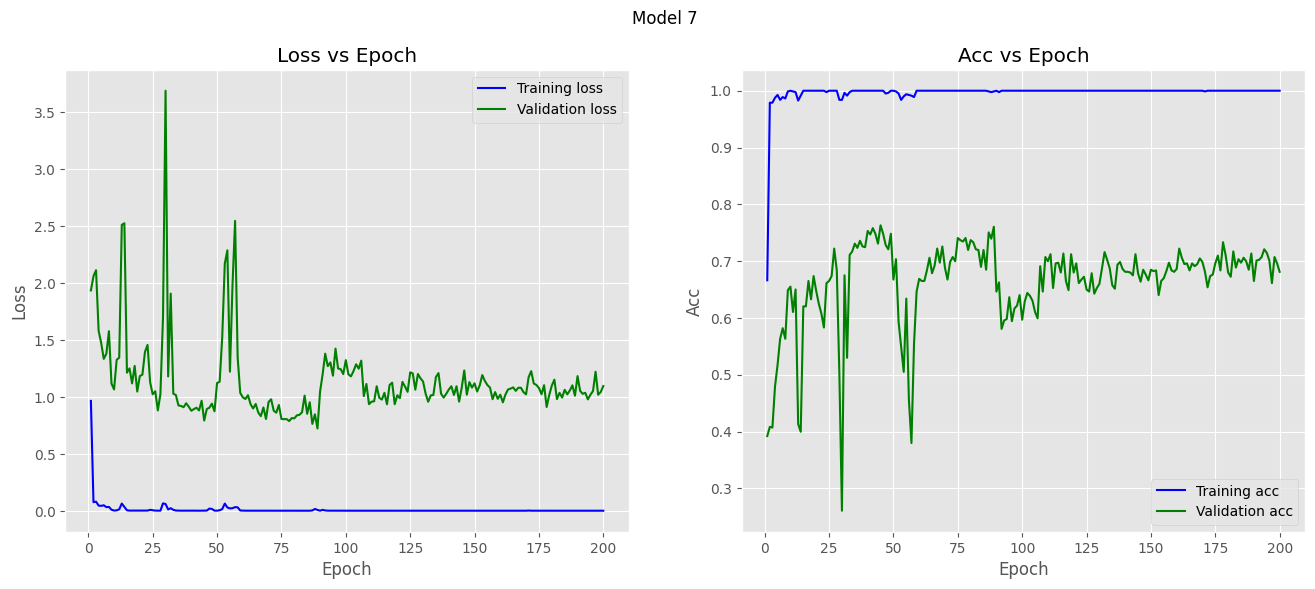

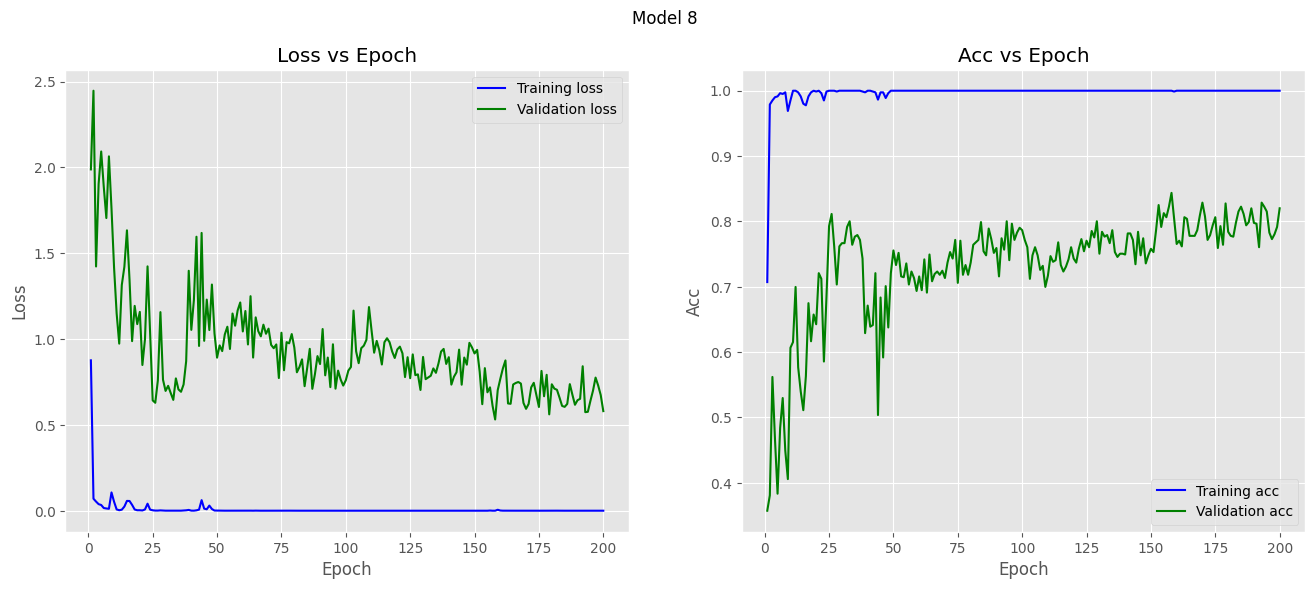

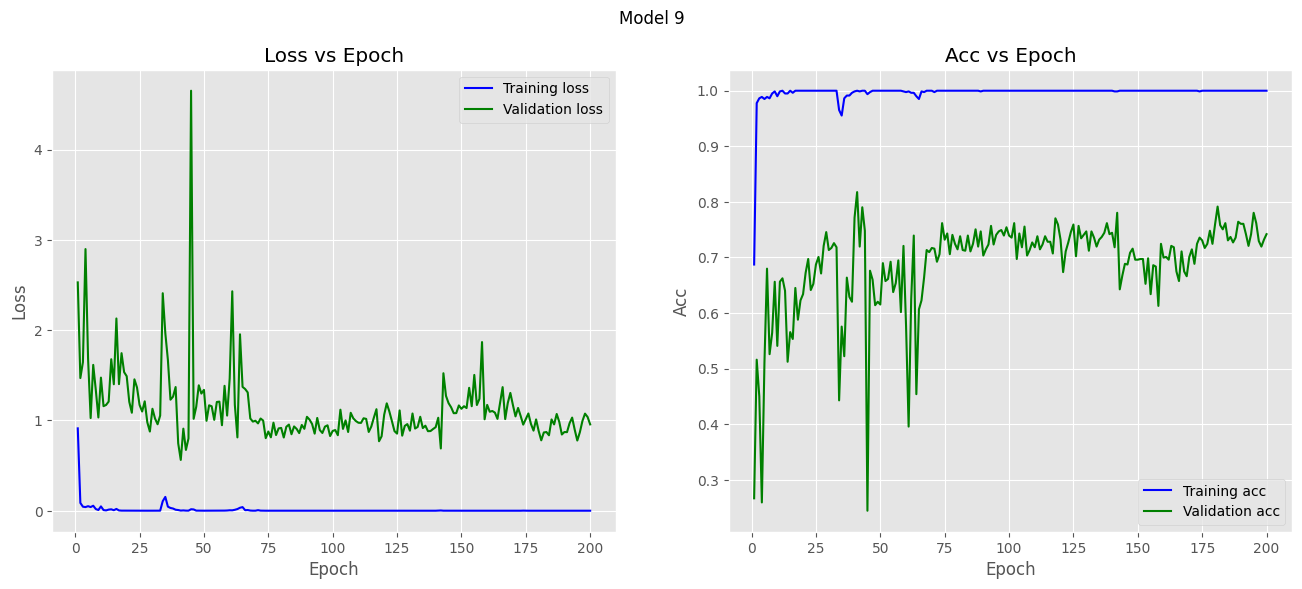

In [13]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}")
        plt.show()

In [14]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.3785
Evaluating Run 1
Test Accuracy: 0.3840
Evaluating Run 2
Test Accuracy: 0.3061
Evaluating Run 3
Test Accuracy: 0.4007
Evaluating Run 4
Test Accuracy: 0.3358
Evaluating Run 5
Test Accuracy: 0.2542
Evaluating Run 6
Test Accuracy: 0.3117
Evaluating Run 7
Test Accuracy: 0.3748
Evaluating Run 8
Test Accuracy: 0.2876
Evaluating Run 9
Test Accuracy: 0.3117


In [15]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.6197
Evaluating Run 1
Test Accuracy: 0.7811
Evaluating Run 2
Test Accuracy: 0.7384
Evaluating Run 3
Test Accuracy: 0.7050
Evaluating Run 4
Test Accuracy: 0.6623
Evaluating Run 5
Test Accuracy: 0.6939
Evaluating Run 6
Test Accuracy: 0.7050
Evaluating Run 7
Test Accuracy: 0.6772
Evaluating Run 8
Test Accuracy: 0.8145
Evaluating Run 9
Test Accuracy: 0.6178


In [16]:
np.array(test_acc_lst).mean() * 100, np.array(test_acc_lst).std() * 100

(np.float64(70.14842300556586), np.float64(6.030369591461144))

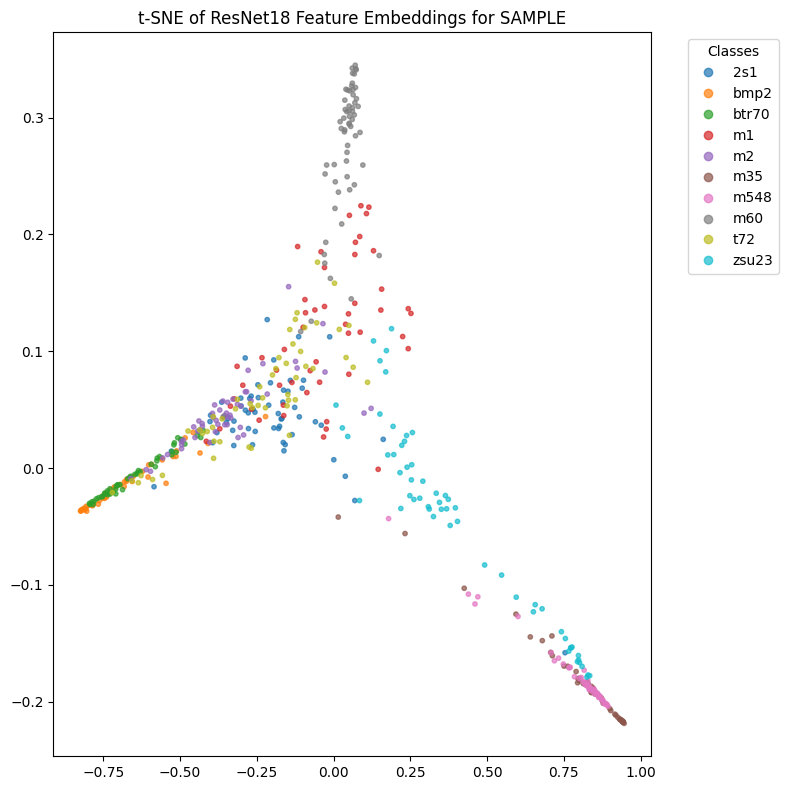

In [18]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run7_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

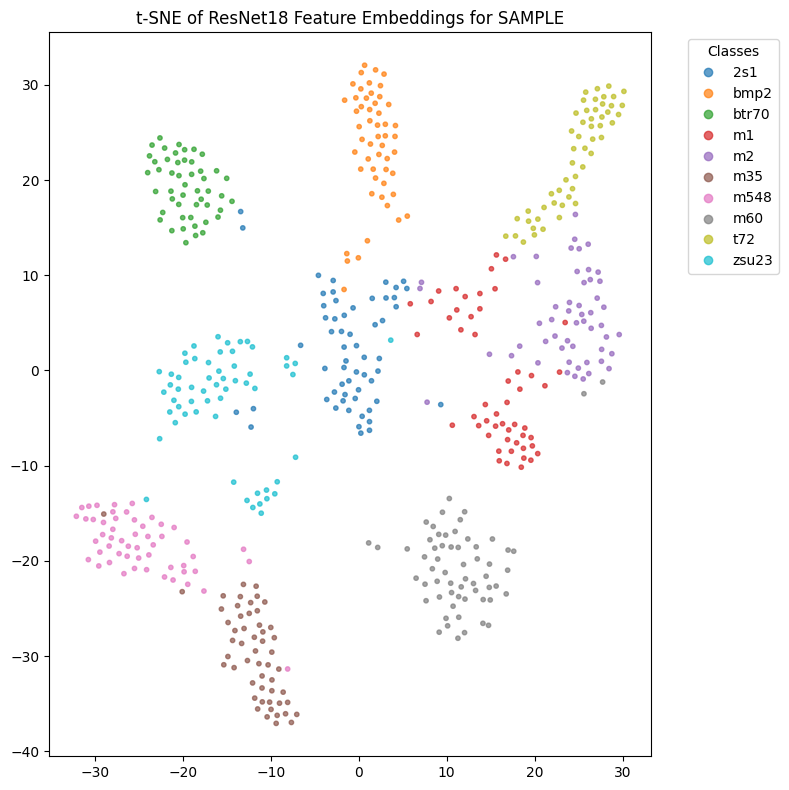

In [19]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run7_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

/home/alvinng44/.local/share/mamba/envs/alyssa/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


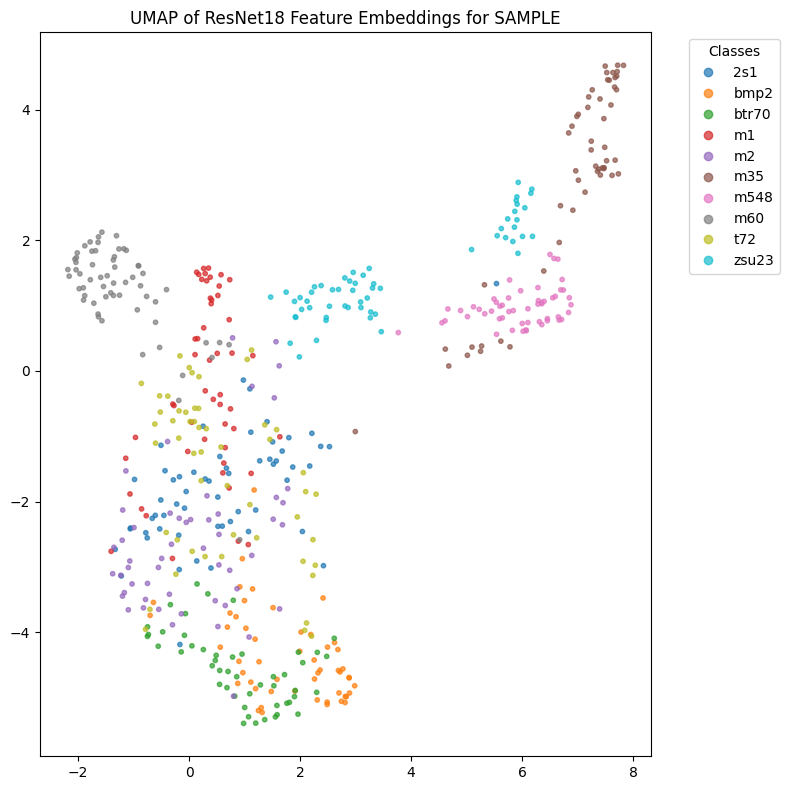

In [20]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run7_b16_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

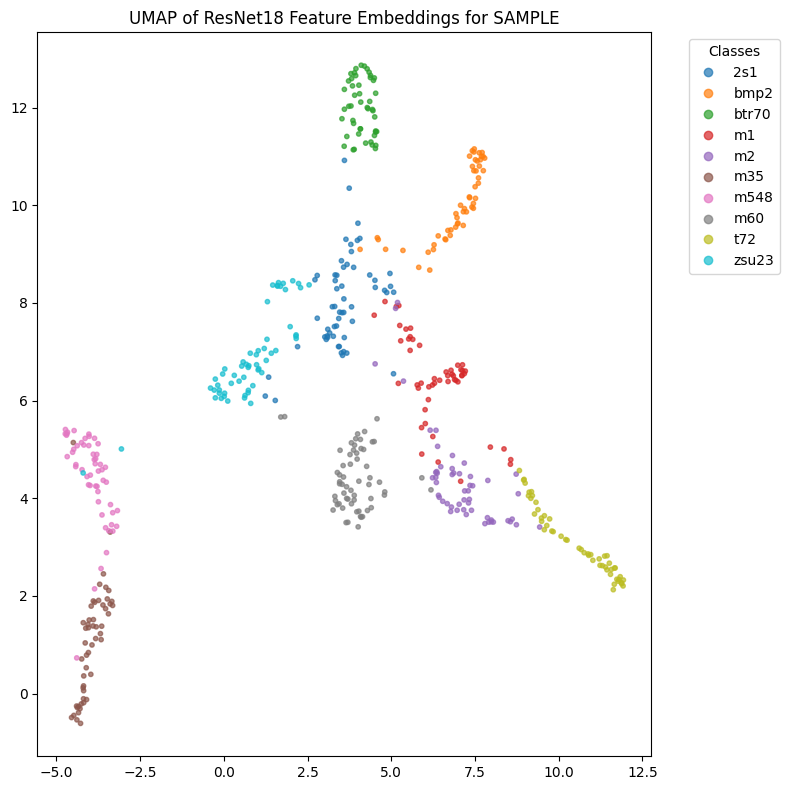

In [22]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run7_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()